# Titanic Data Cleaning & Preprocessing

## Synent Technologies Internship – Task 1

### Submitted by Intern ID: ST-SYN/M2/IP980  ---  Ved Patel

## Objective

The objective of this project is to clean and preprocess the Titanic dataset by handling missing values, removing duplicates, converting data types, renaming columns, and preparing the dataset for further analysis.

## Handling Missing Values

Missing values can affect analysis and model performance. Here we fill missing values in Age and Embarked columns.

### 1. Importing Libraries

In [29]:
import pandas as pd
import numpy as np

### 2. Loading Dataset

In [30]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

### 3. Viewing First 5 Rows

In [31]:
from IPython.display import display
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 4. Checking Dataset Information

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 5. Handling Missing Values

In [33]:
print("Shape before cleaning:", df.shape)
print("Missing values before handling:")
display(df.isnull().sum())

# Filling 'Age' column with its mean
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Filling 'Embarked' column with its mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Dropping the 'Cabin' column
df.drop(columns=['Cabin'], inplace=True)

print("\nMissing values after handling:")
display(df.isnull().sum())

Shape before cleaning: (891, 12)
Missing values before handling:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0



Missing values after handling:


/tmp/ipykernel_3386/2798916611.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_3386/2798916611.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### 6. Removing Duplicates

In [34]:
print("Duplicate rows:", df.duplicated().sum())
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]
print(f"Removed {initial_rows - final_rows} duplicate rows.")
print("Shape after cleaning:", df.shape)

Duplicate rows: 0
Removed 0 duplicate rows.
Shape after cleaning: (891, 11)


### 7. Renaming Columns

In [35]:
df.rename(columns={'PassengerId': 'Passenger_ID', 'Survived': 'Survival_Status'}, inplace=True)
display(df.head())

,Passenger_ID,Survival_Status,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


### 8. Converting Data Types

In [36]:
df['Age'] = df['Age'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passenger_ID     891 non-null    int64  
 1   Survival_Status  891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Name             891 non-null    object 
 4   Sex              891 non-null    object 
 5   Age              891 non-null    int64  
 6   SibSp            891 non-null    int64  
 7   Parch            891 non-null    int64  
 8   Ticket           891 non-null    object 
 9   Fare             891 non-null    float64
 10  Embarked         891 non-null    object 
dtypes: float64(1), int64(6), object(4)
memory usage: 76.7+ KB


### 9. Saving Cleaned Dataset

In [37]:
df.to_csv("Cleaned_Titanic_Dataset.csv", index=False)
print("Cleaned dataset saved to 'Cleaned_Titanic_Dataset.csv'")

Cleaned dataset saved to 'Cleaned_Titanic_Dataset.csv'


### 10. Adding Basic Visualizations

## Data Visualization

Visualizations help identify patterns, trends, and relationships within the cleaned dataset.

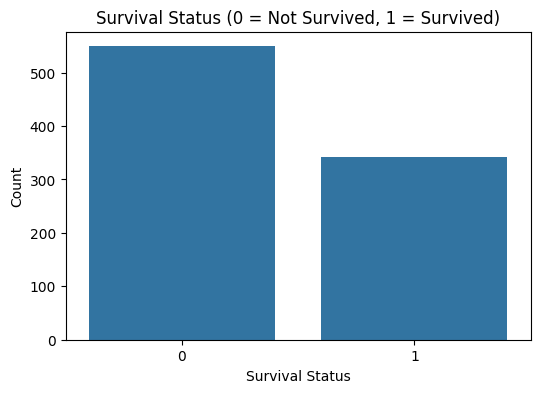

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot for 'Survival_Status'
plt.figure(figsize=(6, 4))
sns.countplot(x='Survival_Status', data=df)
plt.title('Survival Status (0 = Not Survived, 1 = Survived)')
plt.xlabel('Survival Status')
plt.ylabel('Count')
plt.show()

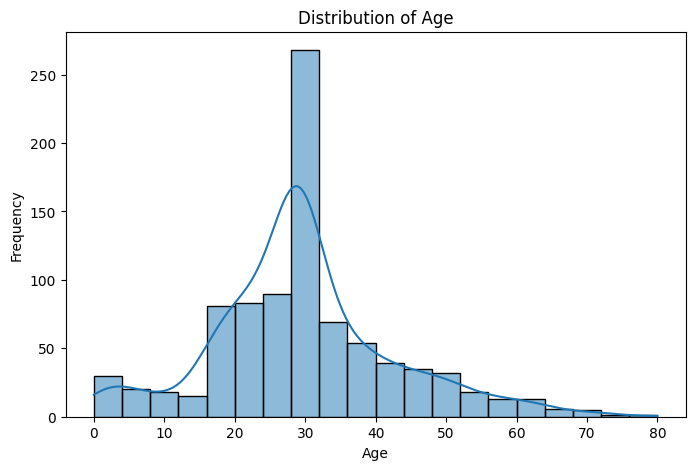

In [39]:
# Histogram for 'Age' distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

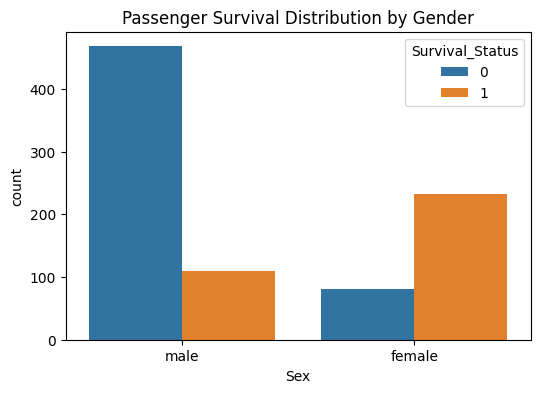

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survival_Status', data=df)
plt.title("Passenger Survival Distribution by Gender")
plt.show()

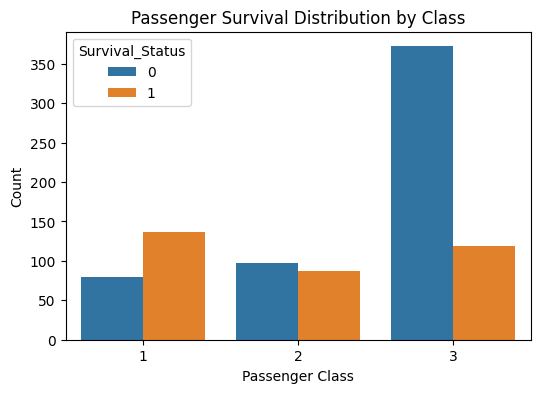

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survival_Status', data=df)
plt.title("Passenger Survival Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

# Key Insights

- Missing values were successfully handled.
- Cabin column was removed due to excessive missing values.
- Most passengers were between age 20–40.
- Female passengers had higher survival rates.
- Dataset is now clean and ready for analysis or machine learning.

# Conclusion

The Titanic dataset was successfully cleaned and preprocessed. The dataset is now suitable for exploratory data analysis and machine learning tasks.